# Scoring granularity: component vs edge vs path vs tree

Given a circuit already discovered by the IPE **tree** search, we pick one node `N` in that tree
and, for **every real candidate predecessor `C`** that `N` could be expanded with, we score the
hypothetical edge `C -> N` four different ways. The point is to see how much a candidate's score
changes as we widen the context it is measured in — in particular to wgich extent the score is aware of
`N`'s **siblings** (the rest of the discovered tree).

All four are counterfactual (name-swapped IOI) and, except `tree`, are reported as a change vs. the
clean run, in the same metric (`logit_difference`) so they are directly comparable.

| score | what is perturbed | context / reference | implementation |
|---|---|---|---|
| **component** | `C`'s whole output at its own token position → cf value | clean model; affects *all* of `C`'s downstream | standalone hook (a real forward pass) |
| **edge** | only `C`'s contribution into `N`'s own input stream/position → cf value | clean model; affects only `N` | standalone hook, ACDC's edge primitive (a real forward pass) |
| **path** | `C`'s message removed along the single chain `C → N → … → root` | isolated path, **no siblings** | IPE `evaluate_path` (message passing) |
| **tree** | `C` attached to `N` inside the whole discovered tree | the found tree, **all siblings jointly ablated** | IPE message passing, leaf-safe `evaluate_tree` marginal |

**The eliciting dimensions of analysis:**
1. *Sibling awareness*: only `tree` conditions on the rest of the discovered circuit. `path` is the
   isolated single-path score the current tree search actually uses; the gap `path` → `tree` is
   exactly the sibling effect.

`edge` reproduces ACDC's edge score (`TLACDCExperiment.step`, `result = evaluated_metric - old_metric`):
cut one connection, measure the real metric change. It is position-aware here (ACDC itself is
position-agnostic) so it lines up with the positional tree nodes.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath("../src"))  # ipe package lives under repo/src

import torch
import numpy as np
import matplotlib.pyplot as plt
import transformers
transformers.logging.set_verbosity_error()

from transformer_lens import HookedTransformer
from transformer_lens.utils import get_device

torch.set_grad_enabled(False)  # everything below is message passing / plain forward passes
device = get_device()

# gpt2-small, configured exactly as the visualization server (center_unembed=True).
model = HookedTransformer.from_pretrained("gpt2-small", device=device, center_unembed=True)
model.eval()

# The edge score severs one connection into a single receiver, so the receiver's per-stream
# input hooks (and the mlp input hook) have to exist. These flags only *expose* hooks; they do
# not change the numerics (same as acdc_bridge does).
model.set_use_split_qkv_input(True)
model.set_use_hook_mlp_in(True)
print(model.cfg.n_layers, "layers,", model.cfg.n_heads, "heads, device", device)

Loaded pretrained model gpt2-small into HookedTransformer
12 layers, 12 heads, device mps


In [2]:
from ipe.experiment import ExperimentManager

# Classic IOI, with a name-swapped counterfactual (same token length).
CLEAN_PROMPTS = ["When Mary and John went to the store, John gave a drink to"]
CF_PROMPTS    = ["When John and Mary went to the store, Mary gave a drink to"]
TARGETS       = [" Mary"]   # correct answer (IO)
CF_TARGETS    = [" John"]   # wrong answer (S) — the other side of the logit difference

# Counterfactual noising: base run = clean, cf activations get patched in, metric measures the
# degradation. patch_clean_into_cf=False keeps it noising. Mirrors the visualization defaults.
experiment = ExperimentManager(
    model=model,
    prompts=CLEAN_PROMPTS,
    targets=TARGETS,
    cf_prompts=CF_PROMPTS,
    cf_targets=CF_TARGETS,
    algorithm="PathMessagePatching",   # unused (we call the tree search directly) but must be valid
    search_strategy="Threshold",
    algorithm_params={},
    metric="logit_difference",
    positional_search=True,
    patch_type="counterfactual",
    patch_clean_into_cf=False,
)

metric      = experiment.metric               # callable: metric(corrupted_resid=...) -> scalar tensor
clean_cache = experiment.cache                # dict, clean run
cf_cache    = experiment.cf_cache             # dict, counterfactual run
clean_tokens = model.to_tokens(CLEAN_PROMPTS, prepend_bos=True)

# No-intervention baseline: the metric on the untouched clean final residual.
M0 = float(metric(corrupted_resid=experiment.clean_final_resid))
str_tokens = model.to_str_tokens(CLEAN_PROMPTS[0], prepend_bos=True)
print("clean-run metric M0 =", round(M0, 4))
print({i: t for i, t in enumerate(str_tokens)})

clean-run metric M0 = 0.0
{0: '<|endoftext|>', 1: 'When', 2: ' Mary', 3: ' and', 4: ' John', 5: ' went', 6: ' to', 7: ' the', 8: ' store', 9: ',', 10: ' John', 11: ' gave', 12: ' a', 13: ' drink', 14: ' to'}


In [3]:
from ipe.graph_search import TreeMessagePatching_LimitedLevelWidth

# Top-k tree, k=10 — the "Top-k" strategy of the visualization (max_width=10). ~1 min on gpt2-small.
K = 10
found_root = TreeMessagePatching_LimitedLevelWidth(
    model, metric, experiment.root, max_width=K, include_negative=True,
)
print("tree search done")

2026-08-17 19:01:02.206 | INFO     | ipe.graph_search:TreeMessagePatching_LimitedLevelWidth:351 - === TreeMessagePatching_LimitedLevelWidth start === root=FINAL_Node(layer=11, position=14) max_width=10 include_negative=True
2026-08-17 19:01:02.206 | DEBUG    | ipe.graph_search:TreeMessagePatching_LimitedLevelWidth:358 - --- depth 0 --- frontier_size=1
  0%|          | 0/1 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|██████████| 1/1 [00:09<00:00,  9.67s/it]
2026-08-17 19:01:11.900 | INFO     | ipe.graph_search:TreeMessagePatching_LimitedLevelWidth:389 - === depth 0 done === scored=2210 admitted=10 next_frontier_size=10
2026-08-17 19:01:11.900 | DEBUG    | ipe.graph_search:TreeMessagePatching_

tree search done


In [4]:
# ---- helpers to read / print the discovered tree -------------------------------------------
def node_name(n):
    cls = type(n).__name__
    if cls == "ATTN_Node":
        h = n.head if n.head is not None else "*"
        streams = "".join(s for s, f in [("Q", n.patch_query), ("K", n.patch_key), ("V", n.patch_value)] if f)
        kv = "" if n.keyvalue_position is None else f",kv={n.keyvalue_position}"
        return f"A{n.layer}H{h}@{n.position}({streams}{kv})"
    if cls == "MLP_Node":
        return f"MLP{n.layer}@{n.position}"
    if cls == "EMBED_Node":
        return f"EMB@{n.position}"
    if cls == "FINAL_Node":
        return f"FINAL@{n.position}"
    return cls

def print_tree(node, prefix="", is_last=True):
    c = getattr(node, "contribution", None)
    tag = f"  [{c:+.3f}]" if c is not None else ""
    print(prefix + ("└─ " if is_last else "├─ ") + node_name(node) + tag)
    kids = sorted(node.children)
    for i, ch in enumerate(kids):
        print_tree(ch, prefix + ("   " if is_last else "│  "), i == len(kids) - 1)

print_tree(found_root)

└─ FINAL@14
   ├─ A9H6@14(Q)  [+2.068]
   ├─ A9H9@14(Q)  [+4.730]
   │  ├─ A8H10@14(Q)  [+0.840]
   │  └─ A8H10@14(KV,kv=10)  [+0.799]
   │     ├─ MLP0@10  [+0.208]
   │     │  ├─ EMB@10  [+0.223]
   │     │  ├─ A0H1@10(Q)  [-0.064]
   │     │  │  └─ EMB@10  [-0.130]
   │     │  └─ A0H10@10(Q)  [+0.059]
   │     └─ A5H9@10(Q)  [+0.244]
   │        ├─ MLP0@10  [+0.049]
   │        │  └─ EMB@10  [+0.089]
   │        ├─ MLP2@10  [+0.042]
   │        │  └─ MLP0@10  [+0.066]
   │        │     ├─ EMB@10  [+0.024]
   │        │     └─ A0H4@10(Q)  [+0.018]
   │        ├─ A3H0@10(Q)  [+0.034]
   │        │  ├─ MLP0@10  [+0.119]
   │        │  │  └─ EMB@10  [+0.174]
   │        │  └─ MLP2@10  [+0.118]
   │        │     └─ MLP0@10  [+0.090]
   │        │        ├─ EMB@10  [+0.039]
   │        │        └─ A0H1@10(Q)  [+0.013]
   │        │           └─ EMB@10  [+0.022]
   │        ├─ A3H0@10(KV,kv=4)  [+0.034]
   │        │  ├─ A0H1@4(KV,kv=4)  [+0.039]
   │        │  │  └─ EMB@4  [+0.035]
   │   

In [ ]:
def expandable_nodes(root):
    out, stack = [], [(root, 0)]
    while stack:
        n, d = stack.pop()
        for ch in sorted(n.children):
            if type(ch).__name__ in ("ATTN_Node", "MLP_Node"):
                out.append((ch, d + 1))
            stack.append((ch, d + 1))
    return out

nodes = expandable_nodes(found_root)
print(f"{'depth':>5}{'#children':>11}{'contribution':>14}  node")
for n, d in sorted(nodes, key=lambda nd: (nd[1], node_name(nd[0]))):
    c = getattr(n, "contribution", None)
    print(f"{d:>5}{len(n.children):>11}{('' if c is None else f'{c:+.3f}'):>14}  {node_name(n)}")

#  name of the node to expand
#(e.g. "A5H9@10") to pin one exactly.
SELECT = "A5H9@10"

matches = [(n, d) for n, d in nodes if node_name(n).startswith(SELECT)]
assert matches, f"no node matching {SELECT!r} in the found tree -- pick one from the list above"
if len(matches) > 1:
    print(f"\n{len(matches)} variants match {SELECT!r}: {[node_name(m) for m, _ in matches]}")
    print("   -> using the one with the most children; refine SELECT to pin another")
    matches.sort(key=lambda nd: -len(nd[0].children))
N, N_depth = matches[0]

candidates = N.get_expansion_candidates(model.cfg, include_head=True)
print(f"\nselected N = {node_name(N)}  |  depth {N_depth}  |  "
      f"{len(N.children)} existing children (siblings)  |  {len(candidates)} candidates to score")
if not N.children:
    print("NOTE: N is a leaf of the found tree, so `tree` measures the marginal of opening a\n"
          "      brand-new branch at N (see the tree-score comment in the next cell).")

depth  #children  contribution  node
    1          0        -1.183  A10H2@14(KV,kv=4)
    1          0        +1.653  A10H6@14(KV,kv=2)
    1          1        -4.100  A10H7@14(KV,kv=2)
    1          4        -3.693  A10H7@14(Q)
    1          1        -1.603  A11H10@14(KV,kv=2)
    1          0        +1.278  A11H1@14(KV,kv=2)
    1          1        +2.368  A9H6@14(KV,kv=2)
    1          0        +2.068  A9H6@14(Q)
    1          1        +5.072  A9H9@14(KV,kv=2)
    1          2        +4.730  A9H9@14(Q)
    2          2        +0.799  A8H10@14(KV,kv=10)
    2          0        +0.840  A8H10@14(Q)
    2          1        -1.522  A9H6@14(KV,kv=2)
    2          1        -1.236  A9H6@14(Q)
    2          1        -1.723  A9H9@14(KV,kv=2)
    2          1        -1.558  A9H9@14(Q)
    2          1        -0.799  MLP0@2
    2          1        -1.585  MLP0@2
    2          1        +1.642  MLP0@2
    2          1        +0.899  MLP0@2
    3          5        +0.244  A5H9@10(Q)
    3 

In [7]:
# ---- the four scores ----------------------------------------------------------------------
from ipe.paths import evaluate_path, get_path

n_layers = model.cfg.n_layers
RESID_LAST = f"blocks.{n_layers - 1}.hook_resid_post"

def write_pos(C):
    """Token position where candidate C makes the contribution relevant to the edge C->N:
    the key/value position for a k/v edge, otherwise C's own (query/mlp) position."""
    if getattr(C, "keyvalue_position", None) is not None and (getattr(C, "patch_key", False) or getattr(C, "patch_value", False)):
        return C.keyvalue_position
    return C.position

def component_vec(C, cache, pos):
    """C's write-vector into the residual stream at `pos`, read from `cache`. Shape [batch, d_model]."""
    cls = type(C).__name__
    if cls == "ATTN_Node":
        z = cache[f"blocks.{C.layer}.attn.hook_z"][:, pos, C.head, :]      # [b, d_head]
        return z @ model.W_O[C.layer, C.head]                              # [b, d_model]
    if cls == "MLP_Node":
        return cache[f"blocks.{C.layer}.hook_mlp_out"][:, pos, :]
    if cls == "EMBED_Node":
        return cache["hook_embed"][:, pos, :]
    raise TypeError(cls)

def _metric_with_hooks(fwd_hooks):
    store = {}
    def grab(x, hook):
        store["r"] = x
    model.run_with_hooks(clean_tokens, fwd_hooks=list(fwd_hooks) + [(RESID_LAST, grab)])
    return float(metric(corrupted_resid=store["r"]))

# (1) COMPONENT: substitute C's whole output at its position with the cf value (real forward).
def score_component(C):
    pos, cls = write_pos(C), type(C).__name__
    if cls == "ATTN_Node":
        name = f"blocks.{C.layer}.attn.hook_z"; val = cf_cache[name][:, pos, C.head, :]
        def h(x, hook, p=pos, hd=C.head, v=val): x[:, p, hd, :] = v; return x
    elif cls == "MLP_Node":
        name = f"blocks.{C.layer}.hook_mlp_out"; val = cf_cache[name][:, pos, :]
        def h(x, hook, p=pos, v=val): x[:, p, :] = v; return x
    else:  # EMBED
        name = "hook_embed"; val = cf_cache[name][:, pos, :]
        def h(x, hook, p=pos, v=val): x[:, p, :] = v; return x
    return _metric_with_hooks([(name, h)]) - M0

# (2) EDGE (ACDC primitive): sever only C's contribution into N's own input stream(s) at `pos`.
#     TLACDCExperiment.step: result = evaluated_metric - old_metric, one edge cut, real forward.
def _edge_streams(C):
    if type(N).__name__ == "MLP_Node":
        return ["mlp"]
    if type(C).__name__ == "ATTN_Node":
        return [s for s, f in [("q", C.patch_query), ("k", C.patch_key), ("v", C.patch_value)] if f]
    # MLP/EMBED candidate into an ATTN receiver: it enters every read at its position (the q/k/v
    # variants at that position dedup to one candidate), so cut all reads at that position.
    return (["q"] if write_pos(C) == N.position else []) + ["k", "v"]

def score_edge(C):
    pos = write_pos(C)
    delta = component_vec(C, cf_cache, pos) - component_vec(C, clean_cache, pos)   # cf - clean
    hooks = []
    for s in _edge_streams(C):
        if s == "mlp":
            name = f"blocks.{N.layer}.hook_mlp_in"
            def h(x, hook, p=pos, d=delta): x[:, p, :] = x[:, p, :] + d; return x
        else:
            name = f"blocks.{N.layer}.hook_{s}_input"
            def h(x, hook, p=pos, hd=N.head, d=delta): x[:, p, hd, :] = x[:, p, hd, :] + d; return x
        hooks.append((name, h))
    return _metric_with_hooks(hooks) - M0

# (3) PATH: isolated single-path score the tree search uses (message passing), no siblings.
#     `suffix` is the FULL ancestor chain [N, ..., root] whatever N's depth; it is bound to the
#     currently selected N in the compute cell below.
def score_path(C):
    return float(evaluate_path([C] + suffix, metric)) - M0

# (4) TREE: marginal of attaching C to N inside the whole discovered tree -- every sibling, at
#     every level, jointly ablated. This is paths.get_tree_msg with one correction: get_tree_msg
#     makes a CHILDLESS node emit its FULL output, so for a leaf N the baseline would ablate all
#     of N while the candidate ablates only the sliver of N that C causes -- a change of regime,
#     not a marginal (and the lost mass is a large constant, near-identical for every C, which
#     swamps the ranking). N therefore emits 0 while it has no child: that is just the k=0 case
#     of the rule "N emits N.forward(sum of its children)", since an empty sum is 0 and
#     N.forward(0) == 0. Identical to get_tree_msg whenever N does have children.
#     Only N is treated this way -- the other leaves are the frozen context we condition on.
ZERO = torch.zeros_like(experiment.clean_final_resid)

def tree_msg(node, extra):
    kids = set(node.children) | ({extra} if node is N and extra is not None else set())
    if not kids:
        return ZERO if node is N else node.forward(message=None)
    return node.forward(message=sum(tree_msg(c, extra) for c in kids))

def tree_value(extra=None):
    return float(metric(corrupted_resid=found_root.forward() - tree_msg(found_root, extra)))

def score_tree(C):
    return tree_value(C) - tree_baseline   # tree_baseline bound in the compute cell below

In [8]:
# Bind the path suffix and the tree baseline to the CURRENTLY selected N, so that changing
# SELECT above and re-running this cell is enough (no need to re-run the definitions).
suffix = get_path(N)          # [N, ..., root] -- full ancestor chain, any depth
tree_baseline = tree_value()  # the found tree as it stands, with N's branch as it stands

# ---- compute -------------------------------------------------------------------------------
# `path` is cheap for every candidate; rank by it and compute the (pricier) component/edge/tree
# only for the strongest TOP_K, to keep the run to ~a couple of minutes. Set TOP_K=None for all.
TOP_K = 40

path_all = np.array([score_path(C) for C in candidates])
order = np.argsort(-np.abs(path_all))
sel = order if TOP_K is None else order[:TOP_K]
if TOP_K is not None and len(candidates) > TOP_K:
    print(f"scoring the top {TOP_K} of {len(candidates)} candidates by |path| "
          f"(dropping {len(candidates) - TOP_K} weaker ones)")

rows = []
for i in sel:
    C = candidates[i]
    rows.append({
        "name": node_name(C),
        "component": score_component(C),
        "edge": score_edge(C),
        "path": float(path_all[i]),
        "tree": score_tree(C),
    })

rows.sort(key=lambda r: abs(r["path"]), reverse=True)
print(f"\n{'candidate':<26}{'component':>11}{'edge':>11}{'path':>11}{'tree':>11}")
for r in rows:
    print(f"{r['name']:<26}{r['component']:>11.4f}{r['edge']:>11.4f}{r['path']:>11.4f}{r['tree']:>11.4f}")

scoring the top 40 of 726 candidates by |path| (dropping 686 weaker ones)

candidate                   component       edge       path       tree
MLP3@10                        0.1568     0.2291     0.1107     0.0000
MLP0@10                        5.3512     0.1649     0.0486     0.0000
MLP2@10                        0.0883     0.0483     0.0421     0.0000
A3H0@10(Q)                     0.0283     0.0572     0.0336     0.0000
A3H0@10(KV,kv=4)               0.0027    -0.0002     0.0335     0.0000
MLP4@10                        0.0724     0.0534     0.0313     0.0025
MLP1@10                        0.2944    -0.0341    -0.0238    -0.0098
A0H4@10(Q)                    -0.0059     0.0447     0.0225     0.0075
A0H4@10(KV,kv=10)             -0.0059     0.0007     0.0199     0.0070
A0H10@10(Q)                   -0.0934     0.0367     0.0198     0.0066
A1H5@10(KV,kv=2)              -0.0161     0.0011     0.0182     0.0024
A0H3@10(Q)                    -0.0015     0.0282     0.0151     0.0044
A0

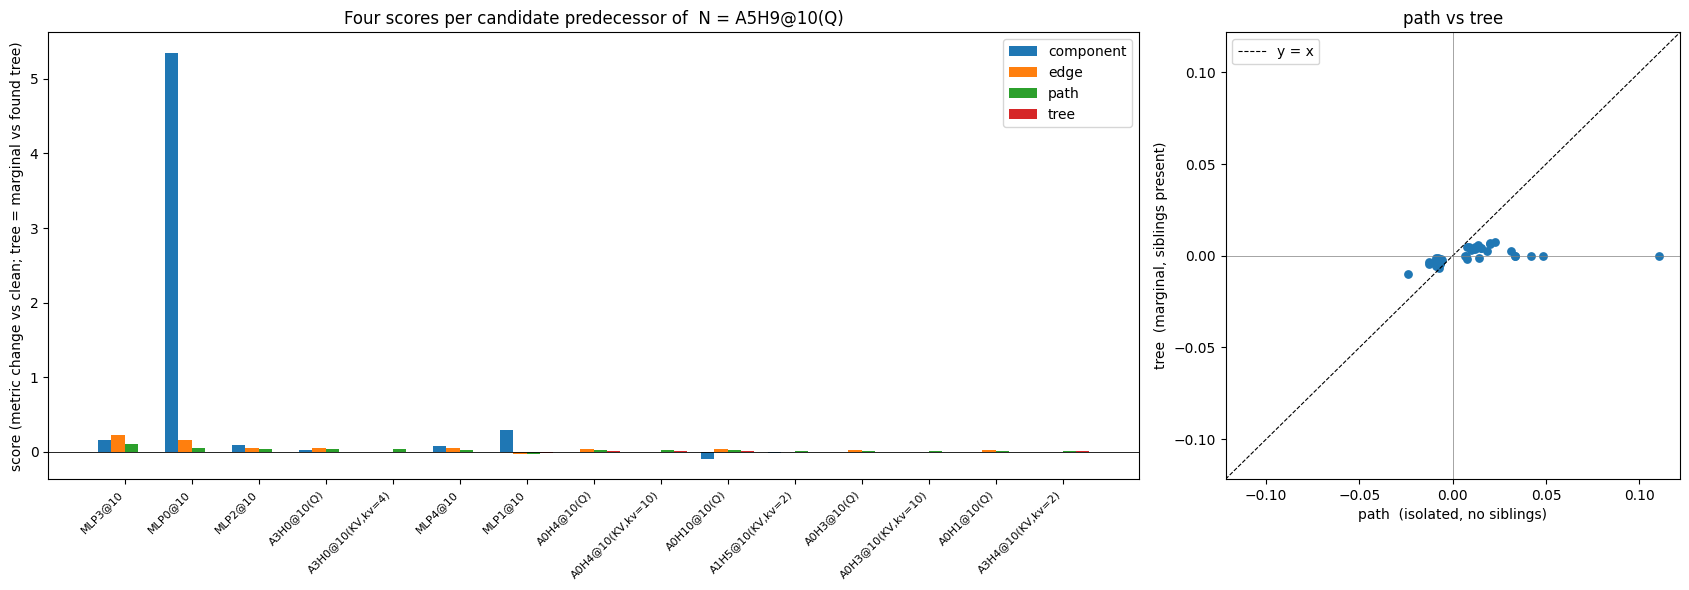

corr(path, tree)      = 0.444
mean |path - tree|    = 0.0138  (sibling effect: 0 => siblings irrelevant here)


In [9]:
# ---- plot ----------------------------------------------------------------------------------
TOP_PLOT = min(15, len(rows))
top = rows[:TOP_PLOT]
labels = [r["name"] for r in top]
series = ["component", "edge", "path", "tree"]
x = np.arange(TOP_PLOT)
w = 0.2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [2.4, 1]})

for j, s in enumerate(series):
    ax1.bar(x + (j - 1.5) * w, [r[s] for r in top], w, label=s)
ax1.axhline(0, color="k", lw=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("score (metric change vs clean; tree = marginal vs found tree)")
ax1.set_title(f"Four scores per candidate predecessor of  N = {node_name(N)}")
ax1.legend()

# path (isolated, no siblings) vs tree (sibling-aware): departures from y=x are the sibling effect.
p = np.array([r["path"] for r in rows]); t = np.array([r["tree"] for r in rows])
ax2.scatter(p, t, s=28)
lim = float(np.abs(np.concatenate([p, t])).max()) * 1.1 + 1e-9
ax2.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, label="y = x")
ax2.axhline(0, color="gray", lw=0.5); ax2.axvline(0, color="gray", lw=0.5)
ax2.set_xlim(-lim, lim); ax2.set_ylim(-lim, lim)
ax2.set_xlabel("path  (isolated, no siblings)")
ax2.set_ylabel("tree  (marginal, siblings present)")
ax2.set_title("path vs tree")
ax2.legend()

plt.tight_layout(); plt.show()

if len(p) > 1:
    print("corr(path, tree)      =", round(float(np.corrcoef(p, t)[0, 1]), 3))
    print("mean |path - tree|    =", round(float(np.abs(p - t).mean()), 4),
          " (sibling effect: 0 => siblings irrelevant here)")